In [32]:
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# GitHub-clone friendly: if this notebook was cloned via git (e.g. by Professor Zong,
# or run locally / on Colab after `!git clone`), PROJECT defaults to the repo root ('.'),
# so data/models/figures resolve as relative folders alongside this notebook.
# Only fall back to a personal Drive path when running in Colab outside of a clone.
if IN_COLAB and not os.path.exists('data'):
    PROJECT = '/content/drive/MyDrive/BYD_Stock_Project_clean'
else:
    PROJECT = '.'

DATA    = f'{PROJECT}/data'
MODELS  = f'{PROJECT}/models'
FIGURES = f'{PROJECT}/figures'
for folder in [DATA, MODELS, FIGURES]:
    os.makedirs(folder, exist_ok=True)

print(f'Project root: {PROJECT}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted, folders ready.


# Stock Price Volatility Analysis — Phase 1: Data Collection & Preparation
**Project:** Construction of Stock Price Volatility Analysis and Prediction Model for Listed Enterprises Based on Multiple Influencing Factors
**Target company:** BYD Co., Ltd (002594.SZ)
**Supervisor:** Professor Ru Zong, Xidian University
**Author:** Petru Andrei Piculescu
**Last updated:** 2026-05

---
This first notebook only collects and cleans the data — no modelling happens here. The goal is a single merged dataset that Phase 2 and Phase 3 can build on directly.

## Notebook structure
1. Environment setup
2. Stock price data (BYD — OHLCV daily, 2015–2025)
3. External influencing factors
4. Data cleaning and temporal alignment
5. Exploratory visualizations
6. Save to disk / Google Drive


## 1. Environment setup
Run this cell first, it installs the libraries needed for the rest of the notebook.


In [33]:
!pip install -q yfinance akshare pandas-datareader matplotlib seaborn scikit-learn openpyxl

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import yfinance as yf
import akshare as ak
import pandas_datareader.data as web

from datetime import datetime
from sklearn.preprocessing import MinMaxScaler

# Plot style used throughout the project, kept consistent across phases
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

START_DATE = '2015-01-01'
END_DATE   = '2025-12-31'

print('Environment ready.')


Environment ready.


## 2. Stock price data — BYD (A-shares, Shenzhen)

Daily OHLCV data for BYD (ticker `002594.SZ`) is fetched from two sources as a cross-check:
- Primary: `akshare` — generally more reliable for Chinese A-share history
- Fallback: `yfinance` — simpler, but can have gaps around Chinese holidays

> **Note on tickers:**
> - `002594.SZ` = A-shares (CNY, Shenzhen Stock Exchange) — this is the one used here
> - `1211.HK`   = H-shares (HKD, Hong Kong Stock Exchange)
> - Both represent BYD but trade in different currencies and markets, so they should not be mixed.


In [34]:
# ak.stock_zh_a_hist returns: 日期, 开盘, 收盘, 最高, 最低, 成交量, 成交额, 振幅, 涨跌幅, 涨跌额, 换手率

print('Downloading BYD A-share data via akshare...')
try:
    byd_ak = ak.stock_zh_a_hist(
        symbol='002594',
        period='daily',
        start_date=START_DATE.replace('-', ''),
        end_date=END_DATE.replace('-', ''),
        adjust='hfq'   # hfq = backward-adjusted for splits and dividends
    )

    byd_ak.rename(columns={
        '日期': 'Date', '开盘': 'Open', '收盘': 'Close',
        '最高': 'High', '最低': 'Low', '成交量': 'Volume',
        '成交额': 'Turnover', '涨跌幅': 'PctChange', '换手率': 'TurnoverRate'
    }, inplace=True)

    byd_ak['Date'] = pd.to_datetime(byd_ak['Date'])
    byd_ak.set_index('Date', inplace=True)
    byd_ak.sort_index(inplace=True)

    print(f'akshare OK: {len(byd_ak)} trading days from {byd_ak.index.min().date()} to {byd_ak.index.max().date()}')
    df_stock = byd_ak[['Open','High','Low','Close','Volume']].copy()

except Exception as e:
    print(f'akshare failed ({e}), falling back to yfinance...')
    byd_yf = yf.download('002594.SZ', start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
    df_stock = byd_yf[['Open','High','Low','Close','Volume']].copy()
    print(f'yfinance OK: {len(df_stock)} trading days')

# yfinance sometimes returns MultiIndex columns even for a single ticker -- flatten if so
if isinstance(df_stock.columns, pd.MultiIndex):
    df_stock.columns = df_stock.columns.get_level_values(0)

print(f'\nShape: {df_stock.shape}')
print(f'Missing values:\n{df_stock.isnull().sum()}')
df_stock.head()


akshare failed (('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))), falling back to yfinance...
yfinance OK: 2671 trading days

Shape: (2671, 5)
Missing values:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-05,12.123049,13.009329,11.948958,12.743445,57644676
2015-01-06,12.464903,13.120117,12.360449,12.765605,41667201
2015-01-07,12.740282,12.740282,12.312968,12.325629,33502194
2015-01-08,12.322463,12.407925,12.148372,12.189521,20675355
2015-01-09,12.199018,12.502886,12.138878,12.167365,25545282


### 2.1 Data cleaning
Handle missing values, trading halts (fairly common for Chinese A-shares), and check the data looks sane before moving on.


In [35]:
# 1. Forward-fill short gaps (<=2 days) -- typically public holidays
df_stock_clean = df_stock.copy()
df_stock_clean = df_stock_clean.ffill(limit=2)

# 2. Drop remaining NaNs (should be zero after the ffill above)
n_dropped = df_stock_clean.isnull().any(axis=1).sum()
df_stock_clean.dropna(inplace=True)
print(f'Rows dropped after ffill: {n_dropped}')

# 3. Trading halts: days where OHLC are all equal usually mean the stock was suspended
halts = df_stock_clean[df_stock_clean['High'] == df_stock_clean['Low']]
print(f'Potential trading halt days (High==Low): {len(halts)}')
if len(halts) > 0:
    print(halts.head(5))

# 4. Extreme single-day returns -- Chinese A-shares have a +/-20% daily limit
df_stock_clean['DailyReturn'] = df_stock_clean['Close'].pct_change()
extreme = df_stock_clean[df_stock_clean['DailyReturn'].abs() > 0.20]
print(f'\nDays with |return| > 20%: {len(extreme)}')
if len(extreme) > 0:
    print(extreme[['Close','DailyReturn']].head(10))

print(f'\nClean dataset: {len(df_stock_clean)} trading days')


Rows dropped after ffill: 0
Potential trading halt days (High==Low): 13
Price            Open       High        Low      Close  Volume
Date                                                          
2015-02-25  15.959378  15.959378  15.959378  15.959378       0
2015-04-24  19.934984  19.934984  19.934984  19.934984       0
2015-04-27  19.934984  19.934984  19.934984  19.934984       0
2015-05-25  24.056185  24.056185  24.056185  24.056185       0
2015-05-26  24.056185  24.056185  24.056185  24.056185       0

Days with |return| > 20%: 0

Clean dataset: 2671 trading days


## 3. External influencing factors

Three core factors that plausibly influence BYD's stock price are collected here:

| Factor | Rationale | Source |
|--------|-----------|--------|
| CNY/USD exchange rate | BYD exports globally; a weaker CNY tends to boost export revenue | FRED (St. Louis Fed) |
| Shanghai Composite Index (000001.SH) | Broad market sentiment / systemic risk proxy | yfinance |
| Lithium carbonate price | Key raw material cost for batteries | akshare (spot price) |

The lithium attempt below is kept in the notebook even though, as noted after cell 11, it doesn't actually work with the data sources tried. Phase 2 revisits and expands the external factor set properly.


In [37]:
# DEXCHUS = China / U.S. Foreign Exchange Rate (CNY per 1 USD)

print('Downloading CNY/USD from FRED...')
try:
    cnyusd = web.DataReader('DEXCHUS', 'fred',
                            start=START_DATE, end=END_DATE)
    if isinstance(cnyusd.columns, pd.MultiIndex):
        cnyusd.columns = cnyusd.columns.get_level_values(0)
    cnyusd.columns = ['CNYUSD']
    cnyusd.index.name = 'Date'
    cnyusd = cnyusd.ffill()   # FRED has weekend gaps
    print(f'CNY/USD OK: {len(cnyusd)} observations')
    cnyusd.tail(3)
except Exception as e:
    print(f'FRED failed: {e}')
    print('  -> https://fred.stlouisfed.org/series/DEXCHUS has a manual CSV download if needed.')
    cnyusd = pd.DataFrame()


CNY/USD OK: 2870 observations


In [38]:
print('Downloading Shanghai Composite (000001.SS) via yfinance...')
sse = yf.download('000001.SS', start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)
sse = sse[['Close']]
if isinstance(sse.columns, pd.MultiIndex):
    sse.columns = sse.columns.get_level_values(0)
sse.columns = ['SSE_Close']
print(f'SSE OK: {len(sse)} trading days')
sse.tail(3)


SSE OK: 2671 trading days


,SSE_Close
Date,
2025-12-26,3963.678955
2025-12-29,3965.280029
2025-12-30,3965.115967


In [39]:
# Lithium carbonate spot price -- attempted via akshare (Chinese commodity data)

print('Attempting lithium carbonate price via akshare...')
try:
    lithium = ak.spot_hist(symbol='碳酸锂')
    lithium['日期'] = pd.to_datetime(lithium['日期'])
    lithium.set_index('日期', inplace=True)
    lithium.index.name = 'Date'
    lithium = lithium[['价格']].rename(columns={'价格': 'Lithium_CNY_ton'})
    lithium = lithium[START_DATE:END_DATE]
    print(f'Lithium OK: {len(lithium)} observations')
except Exception as e:
    print(f'akshare lithium endpoint failed ({e})')
    try:
        lithium = ak.macro_china_lithium_price()
        lithium['日期'] = pd.to_datetime(lithium['日期'])
        lithium.set_index('日期', inplace=True)
        lithium.index.name = 'Date'
        lithium.columns = ['Lithium_CNY_ton']
        lithium = lithium[START_DATE:END_DATE]
        print(f'Lithium (fallback) OK: {len(lithium)} observations')
    except Exception as e2:
        print(f'Both lithium endpoints failed ({e2}). No free, reliable historical source was found for this factor.')
        lithium = pd.DataFrame(columns=['Lithium_CNY_ton'])

if isinstance(lithium.columns, pd.MultiIndex):
    lithium.columns = lithium.columns.get_level_values(0)
if not lithium.empty:
    print(lithium.tail(3))
else:
    print('Lithium series is empty -- excluded from the merged dataset below and from every phase after this one. '
          'This is a known gap: the two free akshare endpoints tried here don\'t return usable battery-grade lithium history, '
          'and a paid source (e.g. Wind, SMM) would be needed to add it properly.')


Attempting lithium carbonate price via akshare...
akshare lithium endpoint failed (module 'akshare' has no attribute 'spot_hist')
Both lithium endpoints failed (module 'akshare' has no attribute 'macro_china_lithium_price'). No free, reliable historical source was found for this factor.
Lithium series is empty -- excluded from the merged dataset below and from every phase after this one. This is a known gap: the two free akshare endpoints tried here don't return usable battery-grade lithium history, and a paid source (e.g. Wind, SMM) would be needed to add it properly.


## 4. Temporal alignment and merged dataset

Everything is resampled onto **BYD's own trading calendar** (the days BYD actually traded), then merged.

> **Important:** gaps in the external factors are filled with `ffill()` (carry the last known value), never `interpolate()`, since interpolation would use future values and leak information the model wouldn't actually have had on that date.


In [41]:
df_merged = df_stock_clean[['Open','High','Low','Close','Volume','DailyReturn']].copy()

if not cnyusd.empty:
    df_merged = df_merged.join(cnyusd, how='left')
    df_merged['CNYUSD'] = df_merged['CNYUSD'].ffill()

if not sse.empty:
    df_merged = df_merged.join(sse[['SSE_Close']], how='left')
    df_merged['SSE_Close'] = df_merged['SSE_Close'].ffill()
    df_merged['SSE_Return'] = df_merged['SSE_Close'].pct_change()

# Lithium is intentionally skipped here -- see note after the lithium cell above.
if not lithium.empty:
    df_merged = df_merged.join(lithium[['Lithium_CNY_ton']], how='left')
    df_merged['Lithium_CNY_ton'] = df_merged['Lithium_CNY_ton'].ffill()

df_merged.dropna(subset=['DailyReturn'], inplace=True)

print(f'Merged dataset shape: {df_merged.shape}')
print(f'Date range: {df_merged.index.min().date()} -> {df_merged.index.max().date()}')
print(f'\nMissing values per column:')
print(df_merged.isnull().sum())
df_merged.head()

Merged dataset shape: (2670, 9)
Date range: 2015-01-06 -> 2025-12-30

Missing values per column:
Open           0
High           0
Low            0
Close          0
Volume         0
DailyReturn    0
CNYUSD         0
SSE_Close      0
SSE_Return     0
dtype: int64


,Open,High,Low,Close,Volume,DailyReturn,CNYUSD,SSE_Close,SSE_Return
Date,,,,,,,,,
2015-01-06,12.464903,13.120117,12.360449,12.765605,41667201,0.001739,6.2125,3351.446045,0.000277
2015-01-07,12.740282,12.740282,12.312968,12.325629,33502194,-0.034466,6.2127,3373.954102,0.006716
2015-01-08,12.322463,12.407925,12.148372,12.189521,20675355,-0.011043,6.2143,3293.456055,-0.023859
2015-01-09,12.199018,12.502886,12.138878,12.167365,25545282,-0.001818,6.2085,3285.412109,-0.002442
2015-01-12,12.180026,12.765604,12.180026,12.496555,34046562,0.027055,6.2027,3229.315918,-0.017074


## 5. Exploratory visualizations
These figures are the basis for the ones used in the report.


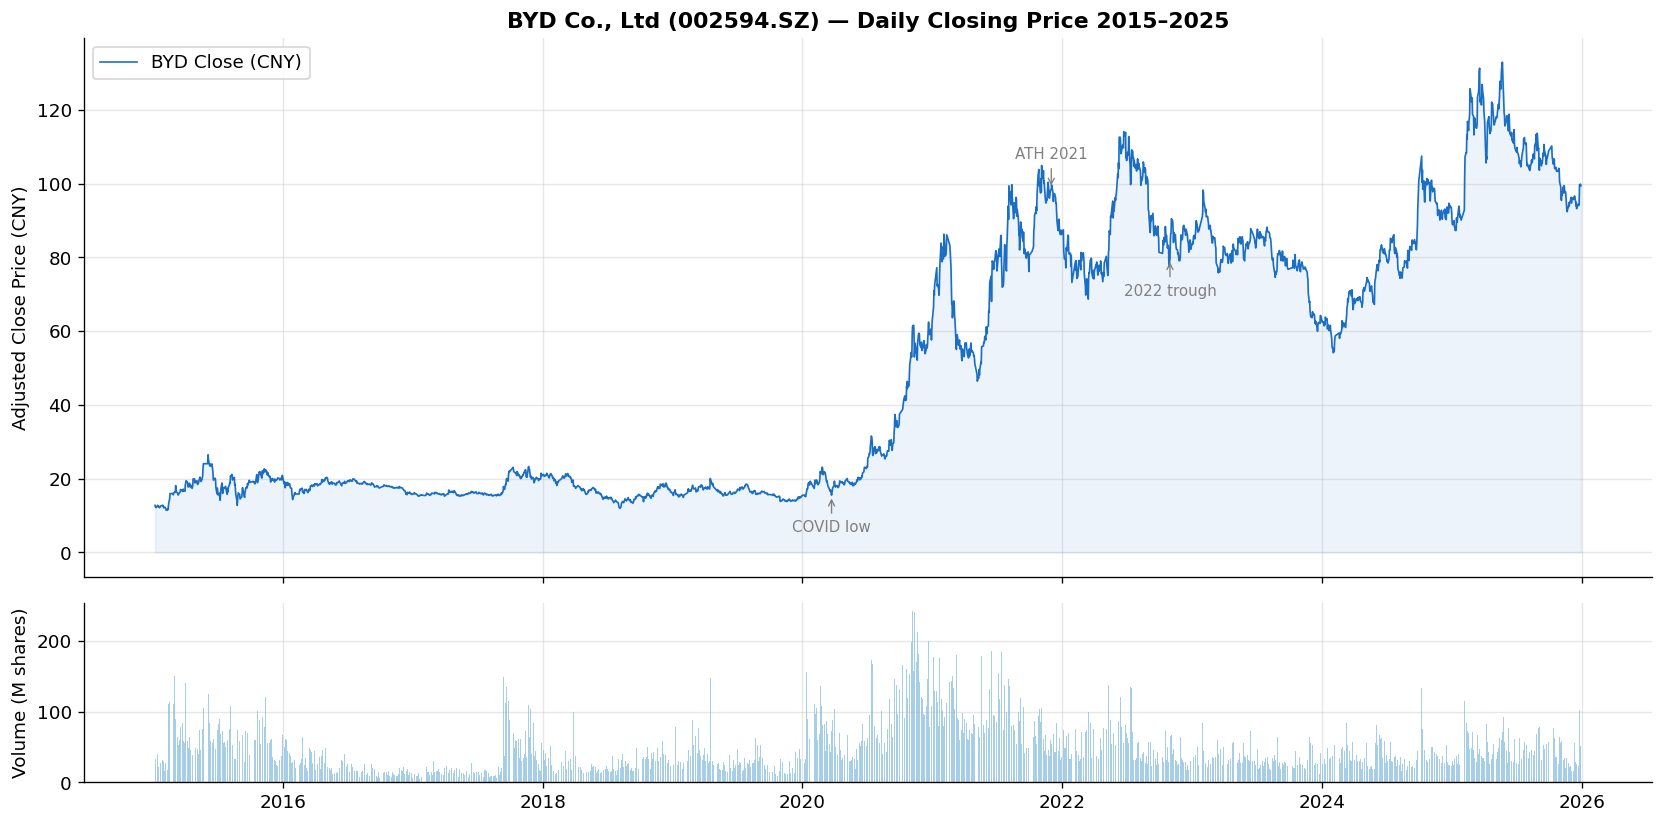

In [42]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

ax1.plot(df_merged.index, df_merged['Close'], color='#1a6fc4', linewidth=1.0, label='BYD Close (CNY)')
ax1.fill_between(df_merged.index, df_merged['Close'], alpha=0.08, color='#1a6fc4')
ax1.set_ylabel('Adjusted Close Price (CNY)')
ax1.set_title('BYD Co., Ltd (002594.SZ) — Daily Closing Price 2015–2025', fontweight='bold')
ax1.legend(loc='upper left')

# A few key dates worth annotating on the chart
events = {
    '2020-03-23': ('COVID low', 'v'),
    '2021-12-01': ('ATH 2021', '^'),
    '2022-10-31': ('2022 trough', 'v'),
}
for date_str, (label, marker) in events.items():
    try:
        d = pd.Timestamp(date_str)
        price = df_merged.loc[df_merged.index >= d, 'Close'].iloc[0]
        ax1.annotate(label, xy=(d, price), xytext=(0, 18 if marker=='^' else -22),
                     textcoords='offset points', ha='center', fontsize=9,
                     arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
                     color='gray')
    except IndexError:
        pass

ax2.bar(df_merged.index, df_merged['Volume'] / 1e6, color='#6baed6', alpha=0.6, width=1)
ax2.set_ylabel('Volume (M shares)')
ax2.set_xlabel('')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(FIGURES + '/fig1_byd_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()


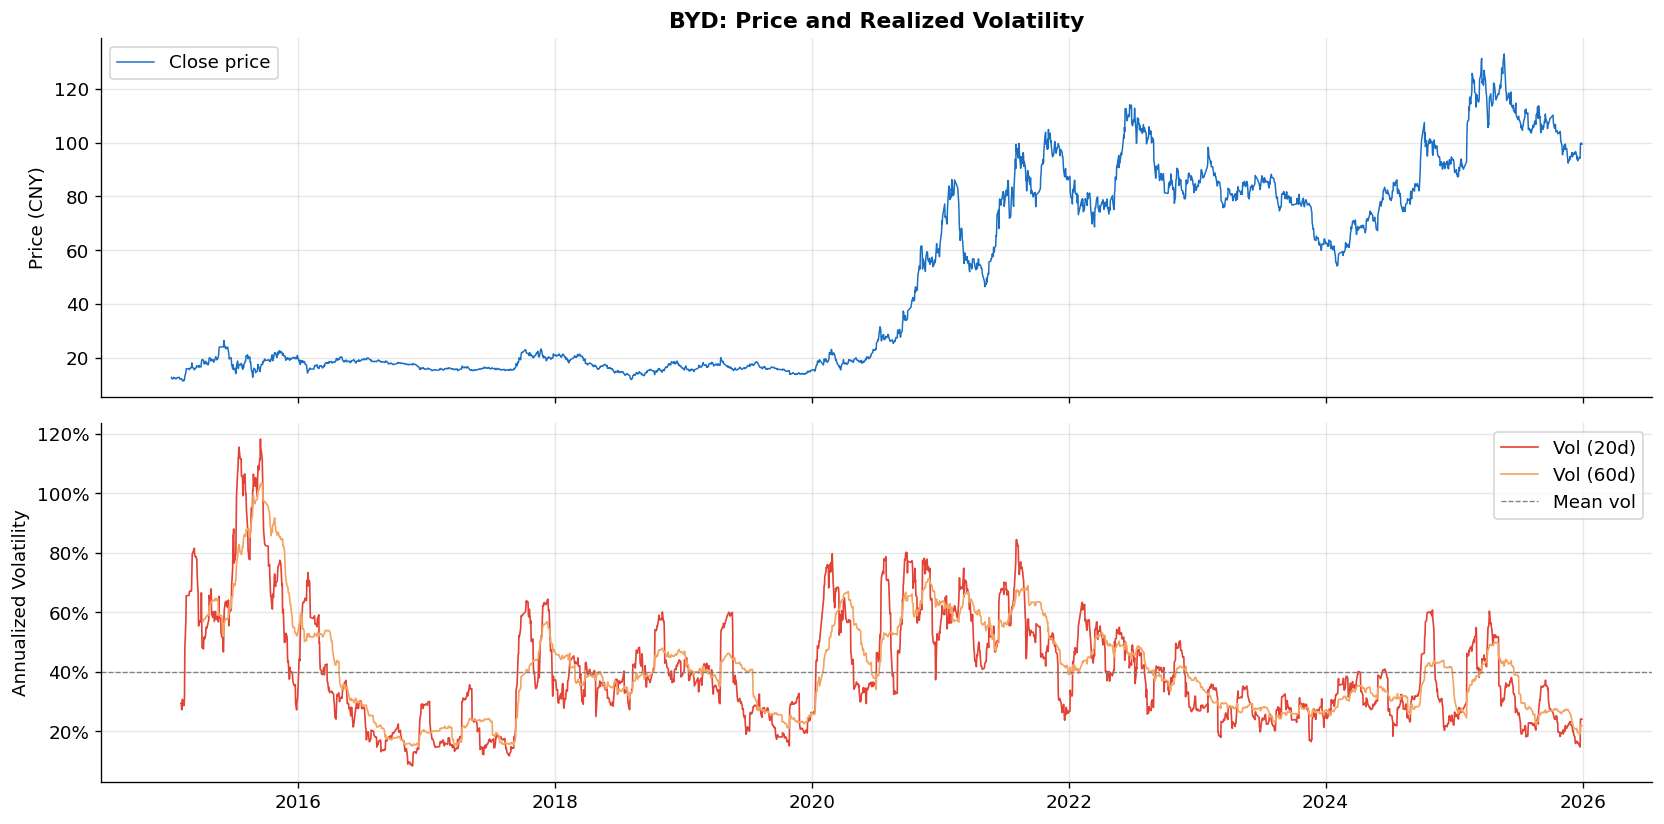

In [43]:
# Rolling realized volatility -- this is the core signal-vs-noise view for BYD

df_merged['Vol_20d'] = df_merged['DailyReturn'].rolling(20).std() * np.sqrt(252)  # annualized
df_merged['Vol_60d'] = df_merged['DailyReturn'].rolling(60).std() * np.sqrt(252)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(df_merged.index, df_merged['Close'], color='#1a6fc4', linewidth=0.9, label='Close price')
ax1.set_ylabel('Price (CNY)')
ax1.set_title('BYD: Price and Realized Volatility', fontweight='bold')
ax1.legend(loc='upper left')

ax2.plot(df_merged.index, df_merged['Vol_20d'], color='#e34234', linewidth=1.0, label='Vol (20d)')
ax2.plot(df_merged.index, df_merged['Vol_60d'], color='#f4a460', linewidth=1.0, label='Vol (60d)')
ax2.axhline(df_merged['Vol_20d'].mean(), linestyle='--', color='gray', linewidth=0.8, label='Mean vol')
ax2.set_ylabel('Annualized Volatility')
ax2.set_xlabel('')
ax2.legend(loc='upper right')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(FIGURES + '/fig2_volatility.png', dpi=150, bbox_inches='tight')
plt.show()


Mean daily return:  0.1153%
Std daily return:   2.7787%
Skewness:           0.387
Kurtosis (excess):  2.730  (>3 -> fat tails, one reason a plain linear model like ARIMA may struggle)


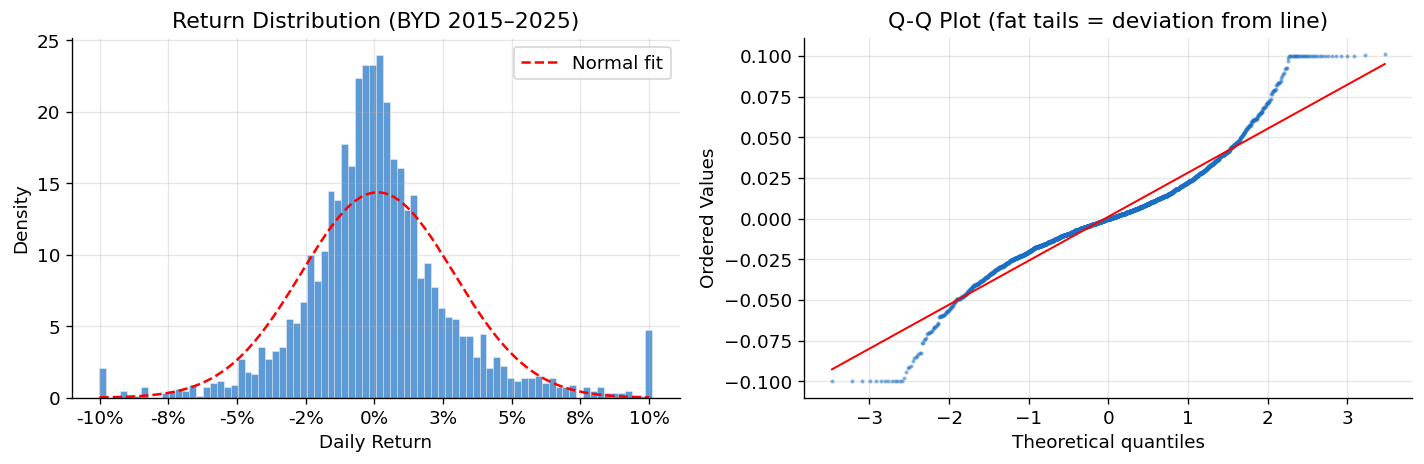

In [44]:
from scipy import stats

returns = df_merged['DailyReturn'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(returns, bins=80, color='#1a6fc4', alpha=0.7, density=True, edgecolor='white', linewidth=0.3)
xmin, xmax = returns.quantile(0.001), returns.quantile(0.999)
x = np.linspace(xmin, xmax, 200)
ax1.plot(x, stats.norm.pdf(x, returns.mean(), returns.std()),
         color='red', linewidth=1.5, linestyle='--', label='Normal fit')
ax1.set_xlabel('Daily Return')
ax1.set_ylabel('Density')
ax1.set_title('Return Distribution (BYD 2015–2025)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.legend()

# Q-Q plot to check for fat tails vs a normal distribution
stats.probplot(returns, dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot (fat tails = deviation from line)')
ax2.get_lines()[0].set(markersize=1.5, alpha=0.4, color='#1a6fc4')
ax2.get_lines()[1].set(color='red', linewidth=1.2)

print(f'Mean daily return:  {returns.mean():.4%}')
print(f'Std daily return:   {returns.std():.4%}')
print(f'Skewness:           {returns.skew():.3f}')
print(f'Kurtosis (excess):  {returns.kurtosis():.3f}  (>3 -> fat tails, one reason a plain linear model like ARIMA may struggle)')

plt.tight_layout()
plt.savefig(FIGURES + '/fig3_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


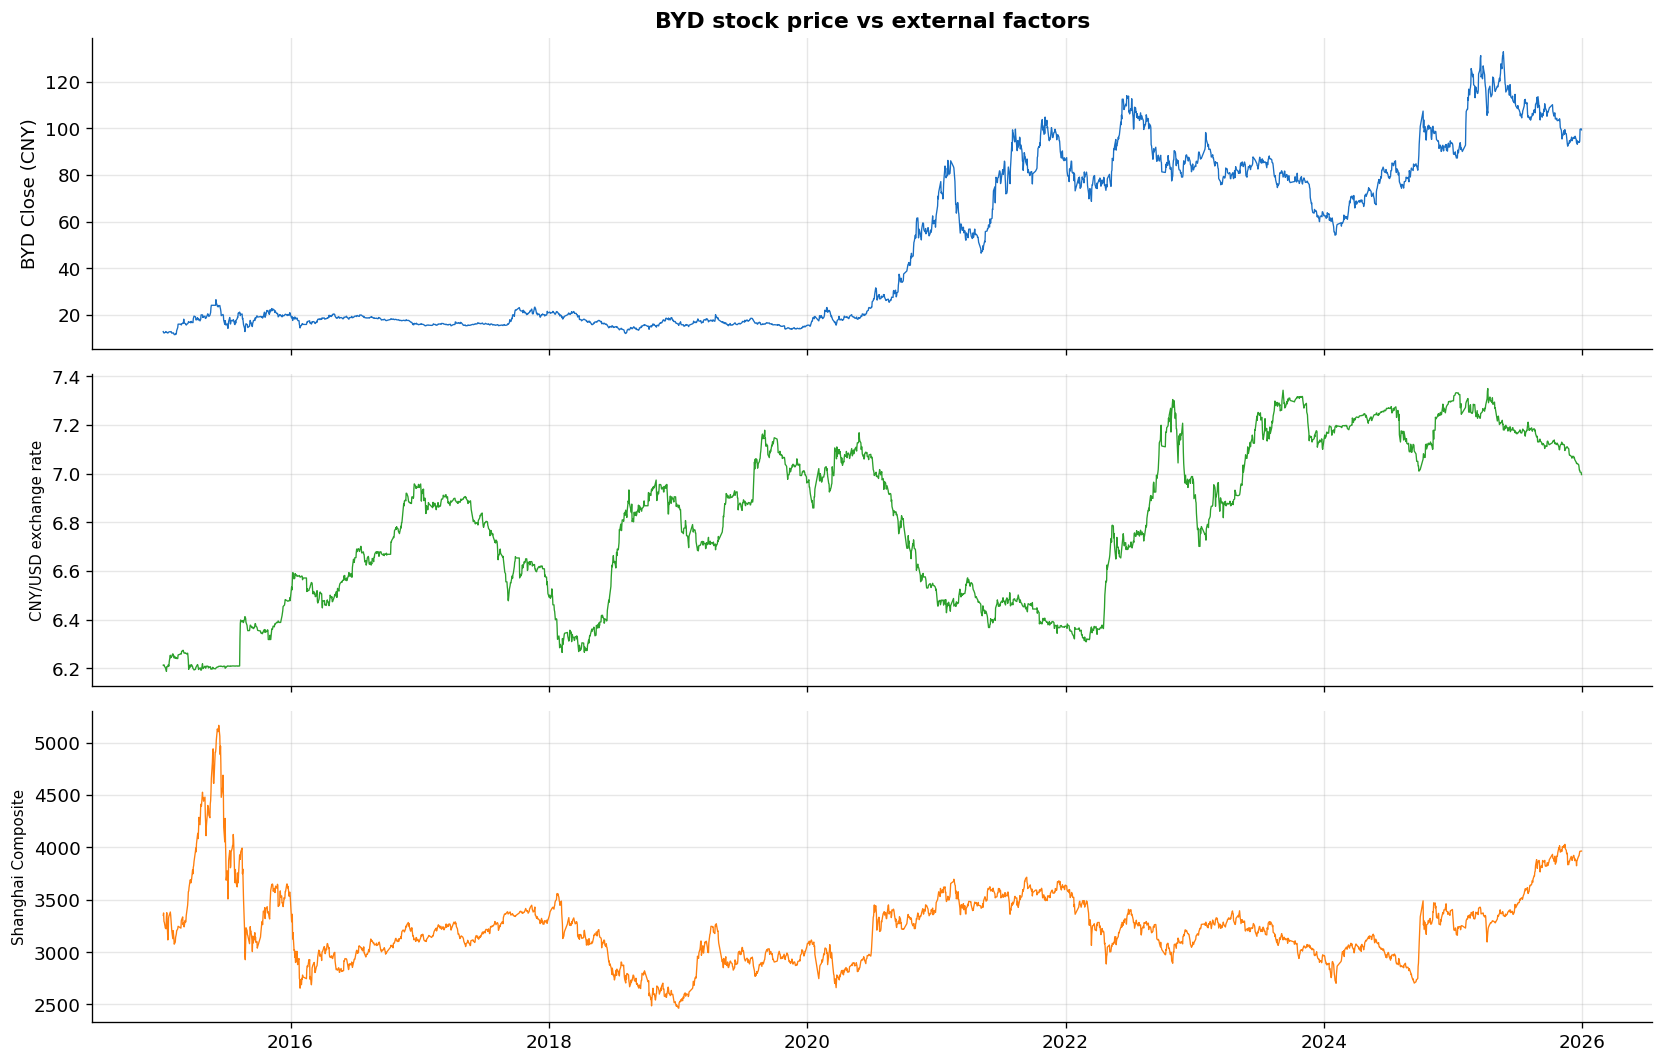

In [45]:
factors_available = []
if 'CNYUSD' in df_merged.columns:     factors_available.append(('CNYUSD', 'CNY/USD exchange rate', '#2ca02c'))
if 'SSE_Close' in df_merged.columns:  factors_available.append(('SSE_Close', 'Shanghai Composite', '#ff7f0e'))
if 'Lithium_CNY_ton' in df_merged.columns: factors_available.append(('Lithium_CNY_ton', 'Lithium carbonate (CNY/ton)', '#9467bd'))

if factors_available:
    n = len(factors_available) + 1  # +1 for BYD price
    fig, axes = plt.subplots(n, 1, figsize=(14, 3*n), sharex=True)

    axes[0].plot(df_merged.index, df_merged['Close'], color='#1a6fc4', linewidth=0.8)
    axes[0].set_ylabel('BYD Close (CNY)')
    axes[0].set_title('BYD stock price vs external factors', fontweight='bold')

    for i, (col, label, color) in enumerate(factors_available, start=1):
        axes[i].plot(df_merged.index, df_merged[col], color=color, linewidth=0.8)
        axes[i].set_ylabel(label, fontsize=9)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.savefig(FIGURES + '/fig4_factors_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No factors available to plot -- check the download cells above.')


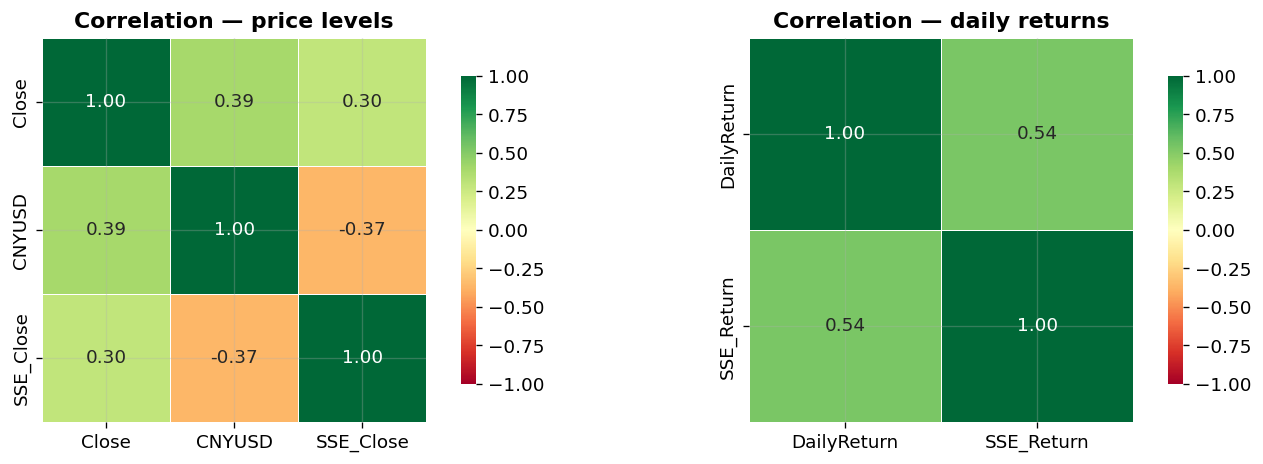

In [46]:
# Correlate both price levels and returns for all available columns

corr_cols_levels  = [c for c in ['Close','CNYUSD','SSE_Close','Lithium_CNY_ton'] if c in df_merged.columns]
corr_cols_returns = [c for c in ['DailyReturn','SSE_Return'] if c in df_merged.columns]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cols, title in zip(axes,
    [corr_cols_levels, corr_cols_returns],
    ['Correlation — price levels', 'Correlation — daily returns']):
    if len(cols) >= 2:
        corr = df_merged[cols].corr()
        mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
        sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                    vmin=-1, vmax=1, square=True,
                    linewidths=0.5, cbar_kws={'shrink': 0.8})
        ax.set_title(title, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(FIGURES + '/fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Summary statistics and data quality report


In [47]:
print('='*60)
print('DATA QUALITY REPORT -- Phase 1')
print('='*60)
print(f'Date range:          {df_merged.index.min().date()} -> {df_merged.index.max().date()}')
print(f'Total trading days:  {len(df_merged)}')
print(f'Columns available:   {list(df_merged.columns)}')
print(f'Missing values:')
for col in df_merged.columns:
    n_miss = df_merged[col].isnull().sum()
    pct = n_miss / len(df_merged) * 100
    flag = 'WARN' if pct > 5 else 'ok'
    print(f'  [{flag}] {col:<25} {n_miss:>5} ({pct:.1f}%)')

print()
print('Descriptive statistics:')
display(df_merged.describe().round(4))


DATA QUALITY REPORT -- Phase 1
Date range:          2015-01-06 -> 2025-12-30
Total trading days:  2670
Columns available:   ['Open', 'High', 'Low', 'Close', 'Volume', 'DailyReturn', 'CNYUSD', 'SSE_Close', 'SSE_Return', 'Vol_20d', 'Vol_60d']
Missing values:
  [ok] Open                          0 (0.0%)
  [ok] High                          0 (0.0%)
  [ok] Low                           0 (0.0%)
  [ok] Close                         0 (0.0%)
  [ok] Volume                        0 (0.0%)
  [ok] DailyReturn                   0 (0.0%)
  [ok] CNYUSD                        0 (0.0%)
  [ok] SSE_Close                     0 (0.0%)
  [ok] SSE_Return                    0 (0.0%)
  [ok] Vol_20d                      19 (0.7%)
  [ok] Vol_60d                      59 (2.2%)

Descriptive statistics:


,Open,High,Low,Close,Volume,DailyReturn,CNYUSD,SSE_Close,SSE_Return,Vol_20d,Vol_60d
count,2670.0000,2670.0000,2670.0000,2670.0000,2.670000e+03,2670.0000,2670.0000,2670.0000,2670.0000,2651.0000,2611.0000
mean,49.9166,50.7582,49.1131,49.9440,4.763606e+07,0.0012,6.7963,3230.8557,0.0001,0.4002,0.4098
std,35.7605,36.2890,35.2308,35.7681,3.544199e+07,0.0278,0.3260,352.3570,0.0127,0.1865,0.1649
min,11.5090,11.5818,11.3665,11.4678,0.000000e+00,-0.1000,6.1870,2464.3630,-0.0849,0.0832,0.1477
25%,17.2969,17.6338,16.9517,17.3210,2.415703e+07,-0.0129,6.4982,3001.1047,-0.0050,0.2694,0.2758
50%,25.6255,25.9040,24.9766,25.4529,3.610049e+07,-0.0001,6.8408,3212.5811,0.0005,0.3561,0.3910
75%,83.0024,84.3080,81.5944,82.9497,6.043972e+07,0.0132,7.0940,3388.2296,0.0059,0.5166,0.5075
max,136.5379,136.5576,132.7967,132.9116,2.423001e+08,0.1011,7.3499,5166.3501,0.0806,1.1816,1.0332


## 7. Save cleaned dataset


In [48]:
df_merged.to_csv(DATA + '/byd_phase1_dataset.csv')
print(f'Phase 1 dataset saved to Drive in: {DATA}')


Phase 1 dataset saved to Drive in: /content/drive/MyDrive/BYD_Stock_Project_clean/data/


---
## Closing note

Phase 1 gives a merged dataset on BYD's trading calendar: OHLCV, daily return, CNY/USD, and the Shanghai Composite (level and return). Lithium carbonate was attempted but dropped -- the two free akshare endpoints tried didn't return usable history, and it isn't carried into any later phase.

Phase 2 replaces this narrow factor set with a larger one (ten factors across market sentiment, currency, commodities, monetary policy, and seasonality), built independently rather than extending this notebook's `cnyusd`/`sse` variables directly.
